# Experiment 2: MF + L1/Lasso weight decay, r x lambda

Exactly Experiment 1's model and training loop, with one line added per
update: an L1/Lasso penalty `lambda * (|A_u|_1 + |B_m|_1)` on the loss,
which becomes a `- lam * sign(...)` term in the per-example gradient step
(see `mf_grid.train_lasso_mf`). Now there are two hyperparameters to
sweep: `r` and `lambda`, selected together by validation RMSE.

`lambda=0` reduces exactly to Experiment 1, so it's included in the grid
as a built-in sanity check / baseline to compare against.

In [1]:
import mf_grid
import numpy as np
import matplotlib.pyplot as plt

print(f"CPU cores available for the pool: {mf_grid.N_THREADS}")

CPU cores available for the pool: 6


In [2]:
data = mf_grid.load_ml100k()
print(f"{data['n_users']} users x {data['n_movies']} movies")
print(f"train={len(data['train_r']):,} val={len(data['val_r']):,} test={len(data['test_r']):,}")

610 users x 9724 movies
train=70,585 val=20,167 test=10,084


In [10]:
r_values   = [1, 2, 3, 4, 6, 8, 12, 20, 35, 60, 100]
lam_values = [0.0, 0.0002, 0.0005, 0.001, 0.002, 0.005,
              0.01, 0.02, 0.03, 0.05, 0.1]
EPOCHS = 60

configs = [{"r": r, "lam": lam} for r in r_values for lam in lam_values]
print(f"{len(configs)} configs ({len(r_values)} r x {len(lam_values)} lambda)")
results = mf_grid.grid_search(configs, data, mf_grid._pool_run_lasso, epochs=EPOCHS, workers=mf_grid.N_THREADS)

121 configs (11 r x 11 lambda)
[1/121] {'r': 1, 'lam': 0.0005} -> val RMSE=0.9511 (68.4s)
[2/121] {'r': 1, 'lam': 0.0} -> val RMSE=0.9513 (70.1s)
[3/121] {'r': 1, 'lam': 0.0002} -> val RMSE=0.9512 (70.7s)
[4/121] {'r': 1, 'lam': 0.001} -> val RMSE=0.9509 (69.6s)
[5/121] {'r': 1, 'lam': 0.002} -> val RMSE=0.9505 (69.2s)
[6/121] {'r': 1, 'lam': 0.005} -> val RMSE=0.9495 (70.6s)
[7/121] {'r': 2, 'lam': 0.0} -> val RMSE=0.9024 (60.8s)
[8/121] {'r': 1, 'lam': 0.05} -> val RMSE=1.0438 (67.6s)
[9/121] {'r': 1, 'lam': 0.02} -> val RMSE=0.9580 (69.5s)
[10/121] {'r': 1, 'lam': 0.03} -> val RMSE=1.0440 (68.7s)
[11/121] {'r': 1, 'lam': 0.01} -> val RMSE=0.9514 (70.9s)
[12/121] {'r': 1, 'lam': 0.1} -> val RMSE=1.0438 (73.6s)
[13/121] {'r': 2, 'lam': 0.0002} -> val RMSE=0.9023 (60.1s)
[14/121] {'r': 2, 'lam': 0.0005} -> val RMSE=0.9021 (59.0s)
[15/121] {'r': 2, 'lam': 0.001} -> val RMSE=0.9018 (59.8s)
[16/121] {'r': 2, 'lam': 0.002} -> val RMSE=0.9012 (61.1s)
[17/121] {'r': 2, 'lam': 0.005} -> val R

In [11]:
# by_cfg = {(cfg["r"], cfg["lam"]): (A, B, train_hist, val_hist) for cfg, A, B, train_hist, val_hist, _secs in results}
mean_val = 0
by_cfg = {}
for cfg, A, B, mean_val, train_hist, val_hist, _secs in results:
    by_cfg[cfg["r"], cfg["lam"]] = (A, B, train_hist, val_hist)
    mean_val = mean_val


best_key = min(by_cfg, key=lambda k: by_cfg[k][3][-1])
best_r, best_lam = best_key
best_A, best_B, _, best_val_hist = by_cfg[best_key]
print(f"best (r, lambda) = ({best_r}, {best_lam}) -> val RMSE = {best_val_hist[-1]:.4f}")

test_rmse = mf_grid.rmse(data["test_u"], data["test_m"], data["test_r"], best_A, best_B, mean_val)
print(f"test RMSE at best (r, lambda) = {test_rmse:.4f}")

best (r, lambda) = (2, 0.01) -> val RMSE = 0.8979
test RMSE at best (r, lambda) = 0.8994


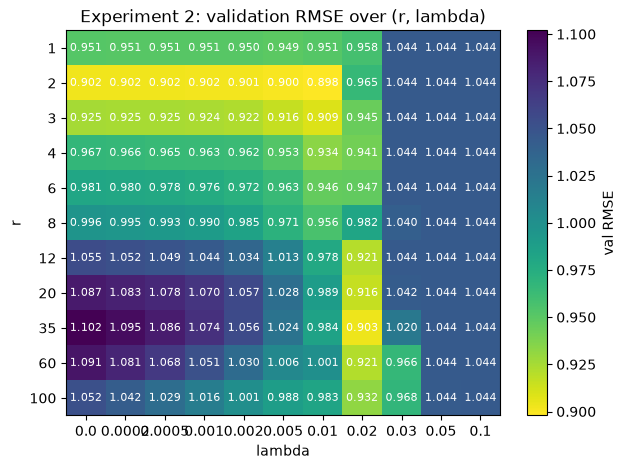

In [12]:
grid = np.array([[by_cfg[(r, lam)][3][-1] for lam in lam_values] for r in r_values])

plt.figure(figsize=(7, 5))
im = plt.imshow(grid, cmap="viridis_r", aspect="auto")
plt.xticks(range(len(lam_values)), lam_values)
plt.yticks(range(len(r_values)), r_values)
plt.xlabel("lambda")
plt.ylabel("r")
plt.title("Experiment 2: validation RMSE over (r, lambda)")
plt.colorbar(im, label="val RMSE")
for i in range(len(r_values)):
    for j in range(len(lam_values)):
        plt.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="white", fontsize=8)
plt.show()

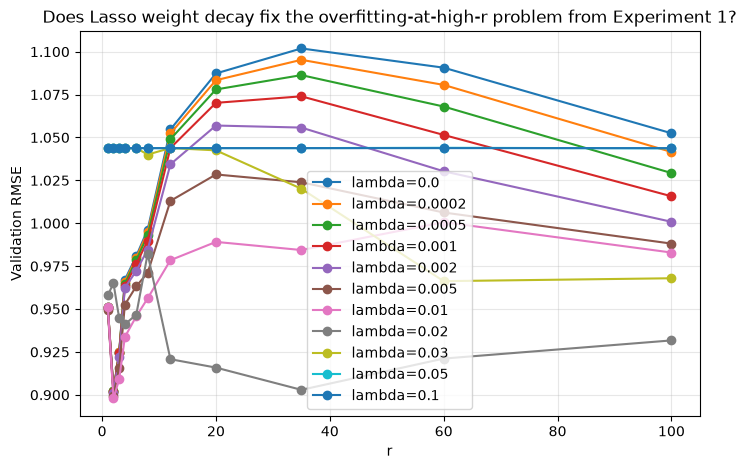

: 

In [ ]:
# lambda=0 here is exactly Experiment 1's model - sanity check the two agree
plt.figure(figsize=(8, 5))
for lam in lam_values:
    plt.plot(r_values, [by_cfg[(r, lam)][3][-1] for r in r_values], marker="o", label=f"lambda={lam}")
plt.xlabel("r")
plt.ylabel("Validation RMSE")
plt.title("Does Lasso weight decay fix the overfitting-at-high-r problem from Experiment 1?")
plt.legend()
plt.grid(alpha=0.3)
plt.show()